### Zad 1. Jak sprawdzić, ile pamięci zużywa DataFrame

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('SalesDataset.csv')
df.head()

,Unnamed: 0,Date,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,0,2023-11-24,Male,34,Beauty,3,50,150
1,1,2023-02-27,Female,26,Clothing,2,500,1000
2,2,2023-01-13,Male,50,Electronics,1,30,30
3,3,2023-05-21,Male,37,Clothing,1,500,500
4,4,2023-05-06,Male,30,Beauty,2,50,100


In [3]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Gender            1000 non-null   object
 3   Age               1000 non-null   int64 
 4   Product Category  1000 non-null   object
 5   Quantity          1000 non-null   int64 
 6   Price per Unit    1000 non-null   int64 
 7   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 205.6 KB


In [4]:
df.memory_usage(deep=True)

Index                 132
Unnamed: 0           8000
Date                59000
Gender              54020
Age                  8000
Product Category    57412
Quantity             8000
Price per Unit       8000
Total Amount         8000
dtype: int64

Najwięcej pamięcu zużywają kolumy:

Date, Gender, Product Category

Są to typy object (rzeczywiśnie w bazie string)

### Zad 2. Generatory, chunkowanie, praca „po kawałkach”

In [5]:
# wykorzystana baza MovieLens 10M 100K

total_rows = 0
chunk_size = 50000

for chunk in pd.read_csv(
        ".\\movielens-10M100K\\ratings.dat",
        sep='::',
        engine='python',
        names=['userId', 'movieId', 'rating', 'timestamp'],
        chunksize=chunk_size):
    total_rows += len(chunk)

print("Liczba wierszy:", total_rows)

Liczba wierszy: 10000054


In [6]:
def czytaj_linie(filename):
    with open(filename, "r", encoding="utf-8") as f:
        for line in f:
            yield line.strip()

In [7]:
czytaj_linie(".\\movielens-10M100K\\moveis.dat")

<generator object czytaj_linie at 0x000001537946D3F0>

In [8]:
# def licz_sume_naiwnie(path):
#     df = pd.read_csv(path)
#     return df["amount"].sum()
def licz_sume_naiwnie(path):
    total_rows_sum = 0
    for chunk in pd.read_csv(path, chunksize=50000):
        total_rows_sum += len(chunk)
    return total_rows_sum

### Zad 3. Wektoryzacja zamiast apply

In [9]:
df = pd.DataFrame({
    "amount":  [500, 1500, 2000, 300],
    "country": ["PL", "PL", "DE", "PL"],
    "discount": [0.1, 0.2, 0.0, 0.15]
})

In [10]:
def compute_final_price(row):
    if row["country"] == "PL" and row["amount"] > 1000:
        return row["amount"] * (1 - row["discount"])
    else:
        return row["amount"]

In [11]:
df["final_price"] = df.apply(compute_final_price, axis=1)
df

,amount,country,discount,final_price
0,500,PL,0.10,500.0
1,1500,PL,0.20,1200.0
2,2000,DE,0.00,2000.0
3,300,PL,0.15,300.0


Wektoryzowane:

In [12]:
# Warunek wektoryzowany
condition = (df["country"] == "PL") & (df["amount"] > 1000)

# Obliczenie final_price
df["final_price"] = np.where(
    condition,
    df["amount"] * (1 - df["discount"]),
    df["amount"]
)

df

,amount,country,discount,final_price
0,500,PL,0.10,500.0
1,1500,PL,0.20,1200.0
2,2000,DE,0.00,2000.0
3,300,PL,0.15,300.0


### Zad *4. Mały „refaktoring juniora”

1.	Zidentyfikuj problemy wydajnościowe / pamięciowe.
2.	Napisz nową wersję funkcji process_sales_optimized(path), która:

-nie tworzy niepotrzebnej kopii,

-używa wektoryzacji zamiast apply,

-optymalizuje typy (category, downcast liczb),

-w razie potrzeby ładuje dane w chunkach (jeśli plik jest bardzo duży).

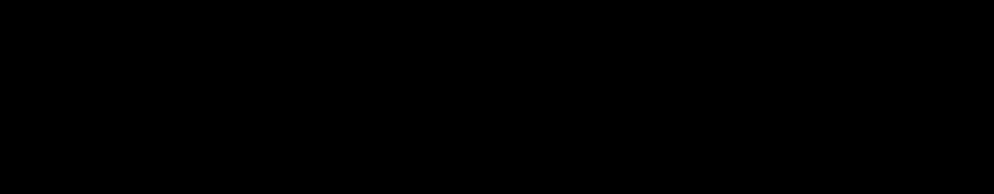
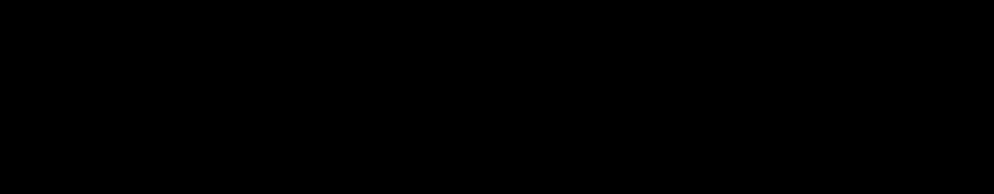
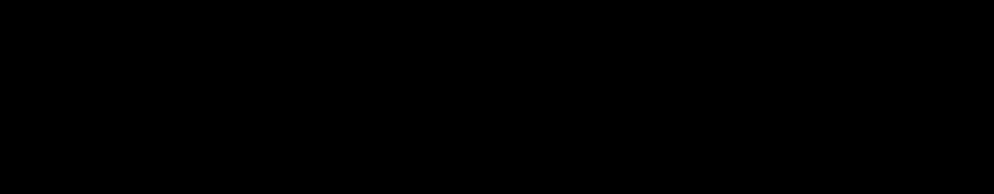

In [13]:
# df = pd.DataFrame({
#     "amount":  [500, 1500, 2000, 300],
#     "country": ["PL", "PL", "DE", "PL"],
#     "discount": [0.1, 0.2, 0.0, 0.15]
# })
# df.to_csv("zad_4_data.csv", index=False)

In [14]:
def process_sales(path):
    df = pd.read_csv(path)
    df = df.copy()

    def flag(row):
        if row["amount"] > 1000 and row["country"] == "PL":
            return 1
        return 0

    df["flag"] = df.apply(flag, axis=1)

    df["country"] = df["country"].astype(str)
    df["product"] = df["product"].astype(str)

    return df

In [15]:
def process_sales_optimazed(path, chunk_size=100000):
    processed_chunks = []

    df = pd.read_csv(path, chunksize=chunk_size)

    for chunk in df:
        mask = (chunk["amount"] > 1000) & (chunk["country"] == "PL")
        chunk["flag"] = mask.astype(int)

        for col in ["country", "product"]:
            chunk[col] = chunk[col].astype("category")

        fcols = chunk.select_dtypes(include=["float"]).columns
        icols = chunk.select_dtypes(include=["integer"]).columns

        chunk[fcols] = chunk[fcols].apply(pd.to_numeric, downcast="float")
        chunk[icols] = chunk[icols].apply(pd.to_numeric, downcast="integer")

        processed_chunks.append(chunk)

    final_df = pd.concat(processed_chunks, ignore_index=True)

    return final_df